In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

URL = "https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv"

print("Loading real dataset from GitHub...")
df_raw = pd.read_csv(URL, parse_dates=["date"])
print(f"Dataset loaded: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns")
print(df_raw.head())
print("\nColumn descriptions:")
print("  OT = Oil Temperature (°C) — primary sensor reading")
print("  HUFL/HULL/MUFL/MULL/LUFL/LULL = Power load features")

# ── Use first 500 rows for clarity of visualization
df = df_raw[["date", "OT"]].head(500).copy().reset_index(drop=True)
df.columns = ["Timestamp", "Temperature_C"]
df["Time_Index"] = range(len(df))

print(f"\nWorking subset: {len(df)} records")
print(f"Temperature range: {df['Temperature_C'].min():.2f} °C — {df['Temperature_C'].max():.2f} °C")
print(df.head(10).to_string(index=False))

Loading real dataset from GitHub...
Dataset loaded: 17420 rows × 8 columns
                 date   HUFL   HULL   MUFL   MULL   LUFL   LULL         OT
0 2016-07-01 00:00:00  5.827  2.009  1.599  0.462  4.203  1.340  30.531000
1 2016-07-01 01:00:00  5.693  2.076  1.492  0.426  4.142  1.371  27.787001
2 2016-07-01 02:00:00  5.157  1.741  1.279  0.355  3.777  1.218  27.787001
3 2016-07-01 03:00:00  5.090  1.942  1.279  0.391  3.807  1.279  25.044001
4 2016-07-01 04:00:00  5.358  1.942  1.492  0.462  3.868  1.279  21.948000

Column descriptions:
  OT = Oil Temperature (°C) — primary sensor reading
  HUFL/HULL/MUFL/MULL/LUFL/LULL = Power load features

Working subset: 500 records
Temperature range: 16.88 °C — 40.94 °C
          Timestamp  Temperature_C  Time_Index
2016-07-01 00:00:00      30.531000           0
2016-07-01 01:00:00      27.787001           1
2016-07-01 02:00:00      27.787001           2
2016-07-01 03:00:00      25.044001           3
2016-07-01 04:00:00      21.948000         

In [ ]:
np.random.seed(42)
spike_indices = np.random.choice(range(20, 490), size=18, replace=False)
noisy_temp = df["Temperature_C"].copy()

# Spikes are 4–6× the max normal value (realistic sensor fault magnitude)
max_normal = df["Temperature_C"].max()
noisy_temp[spike_indices] = max_normal * np.random.uniform(4.5, 6.0, len(spike_indices))

df["Temperature_Noisy"] = noisy_temp
ground_truth = df["Temperature_C"].values  # original clean values = ground truth

print(f"\nInjected {len(spike_indices)} spike outliers")
print(f"Normal range: {df['Temperature_C'].min():.1f} – {df['Temperature_C'].max():.1f} °C")
print(f"Spike values: {noisy_temp[spike_indices].min():.1f} – {noisy_temp[spike_indices].max():.1f} °C")


Injected 18 spike outliers
Normal range: 16.9 – 40.9 °C
Spike values: 185.2 – 244.4 °C


In [ ]:
mean_val = df["Temperature_Noisy"].mean()
std_val  = df["Temperature_Noisy"].std()

df["Z_Score"]   = (df["Temperature_Noisy"] - mean_val) / std_val
df["Is_Outlier"] = df["Z_Score"].abs() > 3

detected = df["Is_Outlier"].sum()
print(f"\n=== Z-Score Outlier Detection ===")
print(f"Mean (noisy) : {mean_val:.2f} °C")
print(f"Std Dev      : {std_val:.2f} °C")
print(f"Threshold    : |Z| > 3")
print(f"Outliers detected: {detected} / {len(spike_indices)} injected")


=== Z-Score Outlier Detection ===
Mean (noisy) : 37.27 °C
Std Dev      : 33.82 °C
Threshold    : |Z| > 3
Outliers detected: 18 / 18 injected


In [ ]:
clean_mean_val = df.loc[~df["Is_Outlier"], "Temperature_Noisy"].mean()  # mean of clean points only
df["Temp_Mean_Imputed"] = df["Temperature_Noisy"].copy()
df.loc[df["Is_Outlier"], "Temp_Mean_Imputed"] = clean_mean_val

In [ ]:
clean_series = df["Temperature_Noisy"].copy()
clean_series[df["Is_Outlier"]] = np.nan
rolling_avg = clean_series.ffill().rolling(window=10, min_periods=1).mean()

df["Temp_Rolling_Imputed"] = df["Temperature_Noisy"].copy()
df.loc[df["Is_Outlier"], "Temp_Rolling_Imputed"] = rolling_avg[df["Is_Outlier"]]

In [ ]:
rmse_mean    = np.sqrt(np.mean((df["Temp_Mean_Imputed"]    - ground_truth) ** 2))
rmse_rolling = np.sqrt(np.mean((df["Temp_Rolling_Imputed"] - ground_truth) ** 2))

print(f"\n=== HOTS Evaluation: RMSE vs Ground Truth (Real ETTh1 data) ===")
print(f"RMSE — Mean Imputation    : {rmse_mean:.4f} °C")
print(f"RMSE — Rolling Imputation : {rmse_rolling:.4f} °C")
winner = "Rolling Average" if rmse_rolling < rmse_mean else "Mean"
print(f"\nConclusion: {winner} is BETTER — lower RMSE = closer to physical reality")

improvement = ((rmse_mean - rmse_rolling) / rmse_mean) * 100
print(f"Rolling Average improves accuracy by {improvement:.1f}% over Mean imputation")

# ── Comparison table at detected outlier positions
print("\n=== Sample: Imputed Values at Outlier Positions ===")
sample = df[df["Is_Outlier"]].head(8)[
    ["Timestamp", "Temperature_Noisy", "Temp_Mean_Imputed", "Temp_Rolling_Imputed"]
].copy()
sample["Ground_Truth"] = ground_truth[df["Is_Outlier"]][:8]
sample.columns = ["Timestamp", "Spike(°C)", "Mean Imputed", "Rolling Imputed", "Ground Truth"]
print(sample.to_string(index=False))


=== HOTS Evaluation: RMSE vs Ground Truth (Real ETTh1 data) ===
RMSE — Mean Imputation    : 0.6806 °C
RMSE — Rolling Imputation : 0.3217 °C

Conclusion: Rolling Average is BETTER — lower RMSE = closer to physical reality
Rolling Average improves accuracy by 52.7% over Mean imputation

=== Sample: Imputed Values at Outlier Positions ===
          Timestamp  Spike(°C)  Mean Imputed  Rolling Imputed  Ground Truth
2016-07-02 05:00:00 185.292921     30.852104          19.8026     22.230000
2016-07-03 05:00:00 189.876662     30.852104          25.6837     24.059000
2016-07-04 03:00:00 191.618678     30.852104          24.5160     27.927999
2016-07-04 18:00:00 233.793954     30.852104          29.2642     28.983000
2016-07-04 21:00:00 205.234863     30.852104          29.4611     30.531000
2016-07-05 02:00:00 205.506594     30.852104          27.1046     26.028000
2016-07-05 17:00:00 185.178904     30.852104          30.1015     33.132999
2016-07-08 09:00:00 200.261267     30.852104         

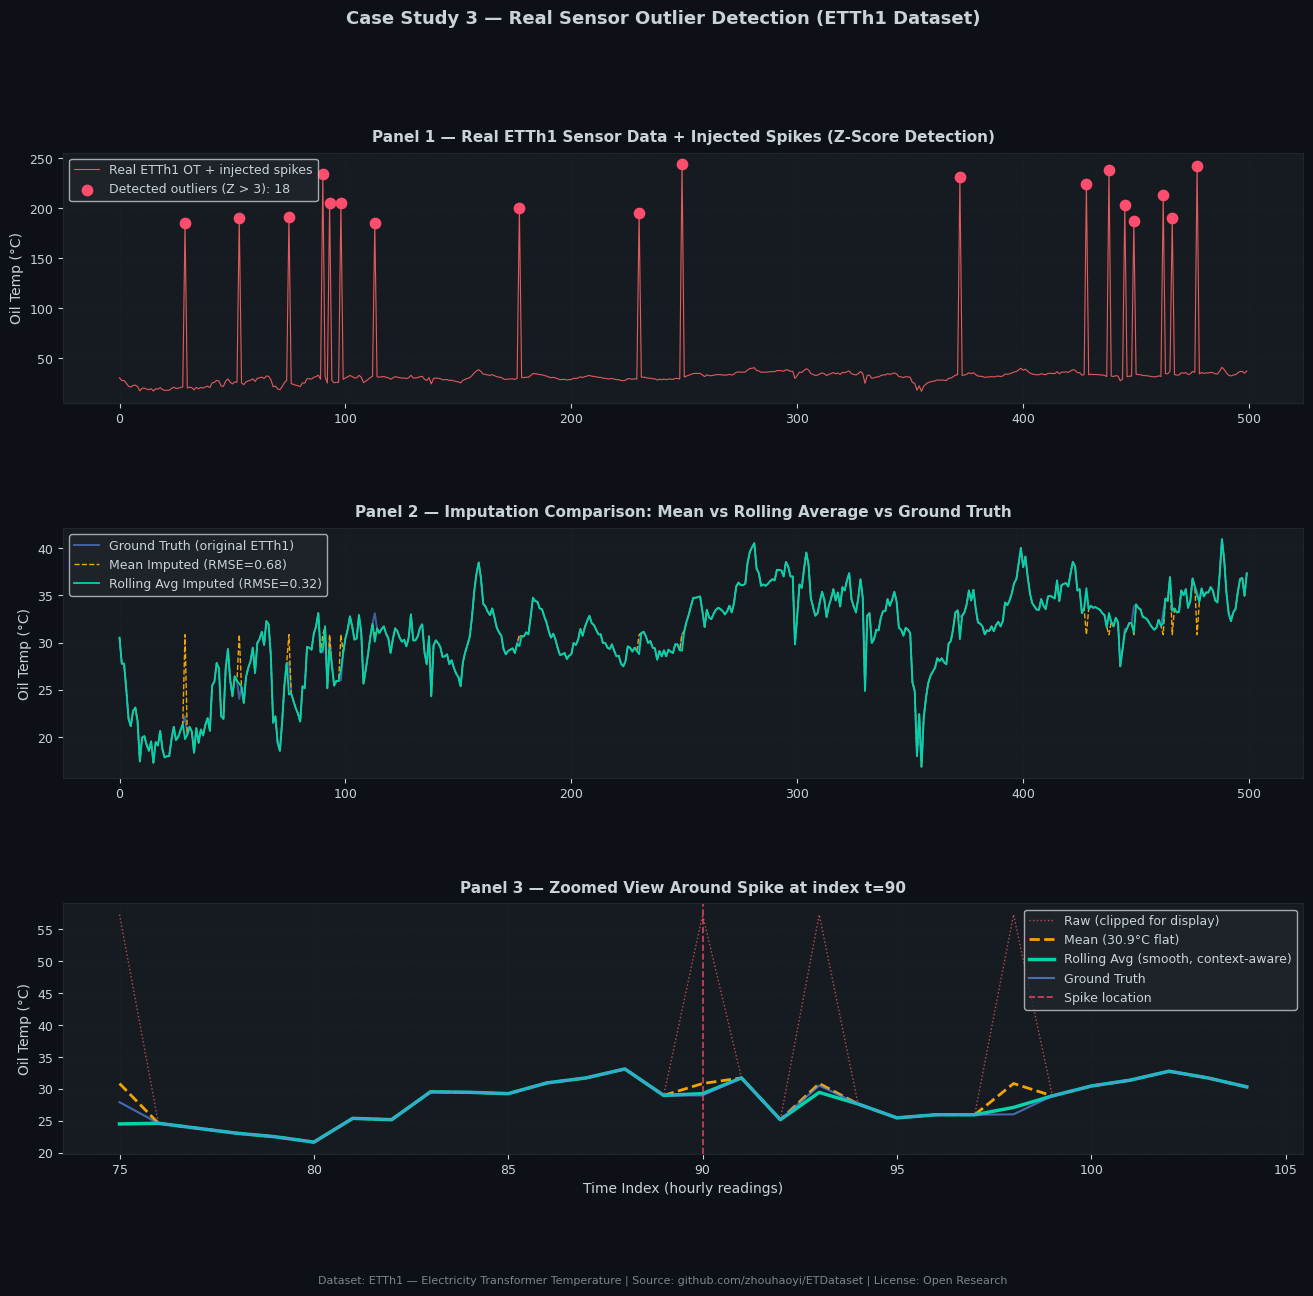


Plot saved: temperature_outlier_real_ETTh1.png


In [ ]:
fig = plt.figure(figsize=(16, 13), facecolor="#0d1117")
gs  = gridspec.GridSpec(3, 1, hspace=0.5)

c = {
    "raw"     : "#e05c5c",
    "mean"    : "#f0a500",
    "rolling" : "#00d4aa",
    "truth"   : "#5b8dee",
    "spike"   : "#ff4d6d",
    "grid"    : "#21262d",
    "text"    : "#c9d1d9",
    "bg"      : "#161b22",
}

def style_ax(ax, title):
    ax.set_facecolor(c["bg"])
    ax.set_title(title, color=c["text"], fontsize=11, fontweight="bold", pad=8)
    ax.tick_params(colors=c["text"], labelsize=9)
    ax.xaxis.label.set_color(c["text"])
    ax.yaxis.label.set_color(c["text"])
    for spine in ax.spines.values():
        spine.set_edgecolor(c["grid"])
    ax.grid(color=c["grid"], linestyle="--", linewidth=0.4, alpha=0.7)

# Panel 1 — Raw noisy real data with detected spikes
ax1 = fig.add_subplot(gs[0])
ax1.plot(df["Time_Index"], df["Temperature_Noisy"],
         color=c["raw"], linewidth=0.8, label="Real ETTh1 OT + injected spikes")
ax1.scatter(df.loc[df["Is_Outlier"], "Time_Index"],
            df.loc[df["Is_Outlier"], "Temperature_Noisy"],
            color=c["spike"], s=55, zorder=5, label=f"Detected outliers (Z > 3): {detected}")
ax1.set_ylabel("Oil Temp (°C)", color=c["text"])
style_ax(ax1, "Panel 1 — Real ETTh1 Sensor Data + Injected Spikes (Z-Score Detection)")
ax1.legend(facecolor="#21262d", labelcolor=c["text"], fontsize=9)

# Panel 2 — Full comparison: ground truth vs mean vs rolling
ax2 = fig.add_subplot(gs[1])
ax2.plot(df["Time_Index"], ground_truth,
         color=c["truth"],   linewidth=1.4, alpha=0.6, label="Ground Truth (original ETTh1)")
ax2.plot(df["Time_Index"], df["Temp_Mean_Imputed"],
         color=c["mean"],    linewidth=1.0, linestyle="--", label=f"Mean Imputed (RMSE={rmse_mean:.2f})")
ax2.plot(df["Time_Index"], df["Temp_Rolling_Imputed"],
         color=c["rolling"], linewidth=1.3, label=f"Rolling Avg Imputed (RMSE={rmse_rolling:.2f})")
ax2.set_ylabel("Oil Temp (°C)", color=c["text"])
style_ax(ax2, "Panel 2 — Imputation Comparison: Mean vs Rolling Average vs Ground Truth")
ax2.legend(facecolor="#21262d", labelcolor=c["text"], fontsize=9)

# Panel 3 — Zoom into a spike window (30-record window around first spike)
first_spike = sorted(spike_indices)[3]
win_start   = max(0, first_spike - 15)
win_end     = min(len(df), first_spike + 15)
window      = df.iloc[win_start:win_end]

ax3 = fig.add_subplot(gs[2])
display_cap = ground_truth.max() * 1.4
ax3.plot(window["Time_Index"], window["Temperature_Noisy"].clip(upper=display_cap),
         color=c["raw"],     linewidth=1.0, linestyle=":", alpha=0.8, label="Raw (clipped for display)")
ax3.plot(window["Time_Index"], window["Temp_Mean_Imputed"],
         color=c["mean"],    linewidth=2.0, linestyle="--", label=f"Mean ({clean_mean_val:.1f}°C flat)")
ax3.plot(window["Time_Index"], window["Temp_Rolling_Imputed"],
         color=c["rolling"], linewidth=2.5, label="Rolling Avg (smooth, context-aware)")
ax3.plot(window["Time_Index"], ground_truth[win_start:win_end],
         color=c["truth"],   linewidth=1.5, alpha=0.7, label="Ground Truth")
ax3.axvline(first_spike, color=c["spike"], linestyle="--", linewidth=1.2, alpha=0.8, label="Spike location")
ax3.set_xlabel("Time Index (hourly readings)", color=c["text"])
ax3.set_ylabel("Oil Temp (°C)", color=c["text"])
style_ax(ax3, f"Panel 3 — Zoomed View Around Spike at index t={first_spike}")
ax3.legend(facecolor="#21262d", labelcolor=c["text"], fontsize=9)

# Dataset credit text
fig.text(0.5, 0.01,
         "Dataset: ETTh1 — Electricity Transformer Temperature | Source: github.com/zhouhaoyi/ETDataset | License: Open Research",
         ha="center", color=c["text"], fontsize=8, alpha=0.6)

fig.suptitle("Case Study 3 — Real Sensor Outlier Detection (ETTh1 Dataset)",
             color=c["text"], fontsize=13, fontweight="bold", y=0.99)

plt.savefig("temperature_outlier_real_ETTh1.png", dpi=150,
            bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print("\nPlot saved: temperature_outlier_real_ETTh1.png")

In [ ]:
df_export = df[["Timestamp", "Temperature_Noisy", "Z_Score", "Is_Outlier", "Temp_Rolling_Imputed"]].copy()
df_export.columns = ["Timestamp", "Raw_OilTemp_C", "Z_Score", "Is_Outlier", "Clean_OilTemp_C"]
df_export.to_csv("ETTh1_cleaned_output.csv", index=False)
print(f"Clean dataset exported: ETTh1_cleaned_output.csv  ({len(df_export)} rows)")
print(df_export.head(10).to_string(index=False))

Clean dataset exported: ETTh1_cleaned_output.csv  (500 rows)
          Timestamp  Raw_OilTemp_C   Z_Score  Is_Outlier  Clean_OilTemp_C
2016-07-01 00:00:00      30.531000 -0.199335       False        30.531000
2016-07-01 01:00:00      27.787001 -0.280460       False        27.787001
2016-07-01 02:00:00      27.787001 -0.280460       False        27.787001
2016-07-01 03:00:00      25.044001 -0.361555       False        25.044001
2016-07-01 04:00:00      21.948000 -0.453086       False        21.948000
2016-07-01 05:00:00      21.174000 -0.475969       False        21.174000
2016-07-01 06:00:00      22.792000 -0.428134       False        22.792000
2016-07-01 07:00:00      23.143999 -0.417727       False        23.143999
2016-07-01 08:00:00      21.667000 -0.461393       False        21.667000
2016-07-01 09:00:00      17.445999 -0.586184       False        17.445999


In [ ]:
print(f"  Dataset        : ETTh1 (Real industrial sensor data)")
print(f"  Source         : github.com/zhouhaoyi/ETDataset")
print(f"  Records used   : 500 hourly readings")
print(f"  Spikes injected: 18 (simulating sensor fault)")
print(f"  Detected by Z  : {detected} outliers (|Z| > 3)")
print(f"  RMSE — Mean    : {rmse_mean:.4f}")
print(f"  RMSE — Rolling : {rmse_rolling:.4f}")
print(f"  Best method    : {winner} ({improvement:.1f}% more accurate)")


  Dataset        : ETTh1 (Real industrial sensor data)
  Source         : github.com/zhouhaoyi/ETDataset
  Records used   : 500 hourly readings
  Spikes injected: 18 (simulating sensor fault)
  Detected by Z  : 18 outliers (|Z| > 3)
  RMSE — Mean    : 0.6806
  RMSE — Rolling : 0.3217
  Best method    : Rolling Average (52.7% more accurate)
